In [1]:
from sklearn.datasets import make_regression
import matplotlib.pyplot as plt
import numpy as np

In [3]:
X,y = make_regression(n_samples=100, n_features=1, n_informative=1,
                     n_targets=1, noise=20, random_state=13)

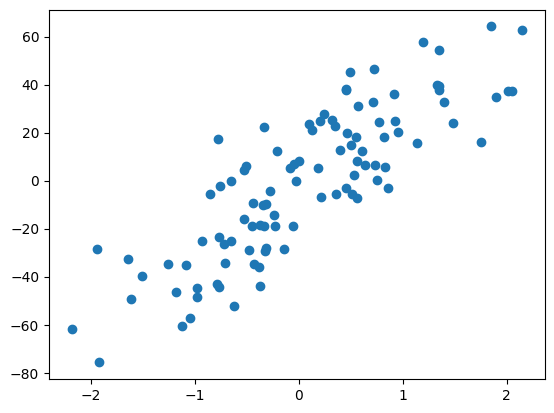

In [5]:
plt.scatter(X,y)

In [7]:
from sklearn.linear_model import LinearRegression

In [11]:
lr = LinearRegression()
lr.fit(X,y)
print(lr.coef_)
print(lr.intercept_)

[27.82809103]
-2.29474455867698


In [13]:
from sklearn.linear_model import Ridge

In [21]:
rr = Ridge(alpha=10)
rr.fit(X,y)
print(rr.coef_)
print(rr.intercept_)

[24.9546267]
-2.1269130035235744


In [23]:
rr1 = Ridge(alpha=100)
rr1.fit(X,y)
print(rr1.coef_)
print(rr1.intercept_)

[12.93442104]
-1.4248441496033315


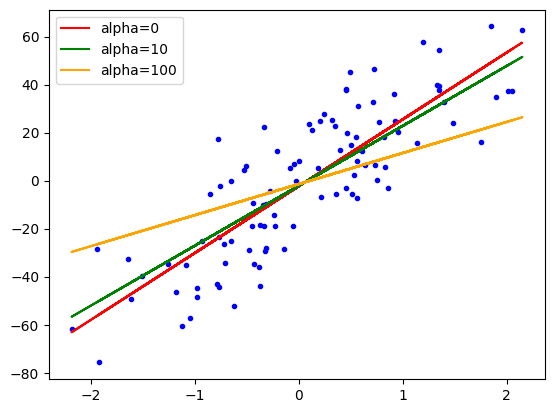

In [27]:
plt.plot(X,y,'b.')
plt.plot(X, lr.predict(X), color='red', label='alpha=0')
plt.plot(X, rr.predict(X), color='green', label='alpha=10')
plt.plot(X, rr1.predict(X), color='orange', label='alpha=100')
plt.legend()

In [51]:
class OwnRidgeRegression:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.m = None
        self.b = None
    def fit(self, X_train, y_train):
        numerator = 0
        denominator = 0
        for i in range(X_train.shape[0]):
            numerator = numerator + (y_train[i] - y_train.mean()) * (X_train[i] - (X_train.mean()))
            denominator = denominator + ((X_train[i] - X_train.mean()) * (X_train[i] - X_train.mean()))
        self.m = numerator / (denominator + self.alpha) 
        self.b = y_train.mean() - (self.m * X_train.mean())
        print(self.m, self.b)
    def predict(X_test):
        pass

In [53]:
reg = OwnRidgeRegression(alpha=10)

In [55]:
reg.fit(X,y)

[24.9546267] [-2.126913]


# Ridge Regression for n-D data

In [1]:
from sklearn.datasets import load_diabetes
from sklearn.metrics import r2_score
import numpy as np

In [2]:
X,y = load_diabetes(return_X_y=True)

In [5]:
from sklearn.model_selection import train_test_split

In [7]:
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [9]:
from sklearn.linear_model import Ridge

In [11]:
reg = Ridge(alpha=0.1, solver='cholesky')

In [13]:
reg.fit(X_train, y_train)

Ridge(alpha=0.1, solver='cholesky')

In [15]:
y_pred = reg.predict(X_test)
r2_score(y_test, y_pred)

0.46931288533098037

In [17]:
print(reg.coef_)
print(reg.intercept_)

[  44.02063391 -241.69329987  452.98665299  332.04420177  -76.33686744
  -68.52143809 -164.98809083  149.96908118  431.61347417   58.51862681]
150.89053425602808


In [37]:
class ND_Ridge:
    def __init__(self, alpha=0.1):
        self.alpha = alpha
        self.coef_ = None
        self.intercept_ = None
    def fit(self, X_train, y_train):
        X_train = np.insert(X_train, 0, 1, axis=1)
        I = np.identity(X_train.shape[1])
        result = np.linalg.inv(np.dot(X_train.T,X_train) + self.alpha* I).dot(X_train.T).dot(y_train)
        self.intercept_ = result[0]
        self.coef_ = result[1:]
    def predict(self, X_test):
        return np.dot(X_test, self.coef_) + self.intercept_

In [39]:
np.identity(X_train.shape[1])

array([[1., 0., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 1., 0., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 1., 0., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 1., 0., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 1., 0., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 1., 0., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 1., 0., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 1., 0., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 1., 0.],
       [0., 0., 0., 0., 0., 0., 0., 0., 0., 1.]])

In [41]:
Nreg = ND_Ridge()
Nreg.fit(X_train, y_train)
print(Nreg.coef_)
print(Nreg.intercept_)

[  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
150.8476272002316


In [43]:
y_pred = Nreg.predict(X_test)
print(r2_score(y_test, y_pred))
print(Nreg.coef_)
print(Nreg.intercept_)

0.46921361559931885
[  44.04252774 -241.72019592  452.99153345  332.06044266  -76.32617866
  -68.54884462 -165.01664054  149.93980143  431.59483654   58.54419942]
150.8476272002316
